# Facial Emotion Recognition Using Visual Transformers

## Introduction

This work is based on the implementation of [keras](https://keras.io/examples/vision/image_classification_with_vision_transformer/). This example implements ViT for classification and demonstrates it on the CIFAR-100 dataset.The ViT model implements the transformer architecture with self-attention to sequences of image patches, without the use of convolution layers.  
*<u>Image Patches and Self-Attention:</u>* In the context of ViT, the input image is divided into non-overlapping patches. These patches are then treated as sequences, and the Transformer's self-attention mechanism is applied to capture the relationships between different patches.  
*<u>There are no levels of convolution:</u>* Unlike traditional convolutional neural networks (CNNs), ViT does not use convolution levels. Instead, it relies on the Transformer's self-attention mechanism to process image segments and learn spatial relationships.

## Setup

In our case we will have to make some adjustments for Facial Emotion Recognition.  
- First, we need to use the appropriate dataset (this dataset should include facial images with corresponding emotion labels): **FER2013** and **AffectNet** are those we are going to use.  
- Then, we need to make some adjustments to the image size. Just because ViT splits te image into patches, the patch created may not adjust based on the characteristics of facial expression images.  
- The layer of the output of the ViT model must also be modified to match the number of classes in our FER dataset. FER2013 has 7 emotion classes (Angry, Disgust, Fear, Happy, Sad, Surprise, Neutral) and AffectNet has 9 [Neutral, Happiness, Sadness, Surprise, Fear, Disgust, Anger, Contempt, None (for images where no specific emotion is detected)]. Therefore, the output layer of our model must have 7 and 9 units, accordingly.  
- After, it has to modify the training configuration such as learning rate, batch size and number of epochs, based on the specifics of FER dataset. Experiment with hyperparameters to achieve better performance.
- Next, choose the appropriate evaluation metrics for FER, such as accuracy, precision recall and F1 score.  
##### *Optional*  
- Fine-tuning the ore-trained ViT model involves training the model on FER dataset after it has been pretrained on a larger dataset.  
- Apply data augmentation techniques to increase the diversity of your training dataset. This can be particularly beneficial for improving the model's ability to recognize facial expressions under different conditions.


### Essential batch commands

*<u>Note:</u>* Make sure you have Kaggle account. On your settings tab create a new token on API section (download .json file and move it to .kaggle folder).

In [40]:
# !pip install ipykernel
!pip install keras==3.0.1
# !pip install tensorflow
!pip install kaggle

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


## Setting backend for Keras to JAX

Jax is a numerical computing library that is particularly well-suited for high-perfomance machine learning operations (matrix multiplications and convolutions). JAX is an alternative backend to TensorFlow and PyTorch.  
ops module provides various operations.
After this setting we can proceed to build our neural network using Keras with JAX backend.

In [41]:
import os
os.environ["KERAS_BACKEND"] = "jax"  # @param ["tensorflow", "jax", "torch"]

import keras
from keras import layers
from keras import ops

import numpy as np
import matplotlib.pyplot as plt

## Prepare Data of FER2013

Import the Kaggle API client and authenticate with your Kaggle credentials:

In [42]:
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

Download the "fer2013" dataset:  
*<u>Note:</u>* The competition_download_files method is used because the "fer2013" dataset was originally part of the "Challenges in Representation Learning: Facial Expression Recognition Challenge." This dataset can still be accessed using the competition name. Inside the competition there is a tab named "Rules" and they must be accepted by the user.

In [43]:
api.competition_download_files('challenges-in-representation-learning-facial-expression-recognition-challenge')

Unzip the downloaded files:

In [44]:
!unzip -o challenges-in-representation-learning-facial-expression-recognition-challenge.zip -d dataset
!tar -zxvf dataset/fer2013.tar.gz
!mv fer2013/*.csv .
!rm -r fer2013 dataset

Archive:  challenges-in-representation-learning-facial-expression-recognition-challenge.zip
  inflating: dataset/example_submission.csv  
  inflating: dataset/fer2013.tar.gz  
  inflating: dataset/icml_face_data.csv  
  inflating: dataset/test.csv        
  inflating: dataset/train.csv       
fer2013/fer2013.csv
fer2013/README
fer2013/fer2013.bib
fer2013/


Modify the formats to create the training and testing shapes.  
<u>*Note:</u>* I change the call of import *from keras.utils.np_utils import to_categorical* and the version of keras cause of this [bug](https://stackoverflow.com/questions/45149341/importerror-cannot-import-name-np-utils)

In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
# from keras.utils.np_utils import to_categorical
from keras.utils import to_categorical

# Load FER2013 dataset from CSV
path = "fer2013.csv"
df = pd.read_csv(path)

# Extract pixel values and emotion labels
pixels = df['pixels'].apply(lambda x: np.fromstring(x, dtype=int, sep=' ')).values
pixels = np.vstack(pixels)
pixels = pixels.reshape((-1, 48, 48, 1))  
# The -1 in the reshape allows NumPy to automatically determine the size of the first dimension
# based on the total number of elements, ensuring that the total number of pixels remains constant.
# The images are 48x48, grayscale (that 's why channels = 1).

emotions = df['emotion'].values
input_shape = (48, 48, 1)
num_classes = 7

# Convert emotion labels to categorical labels
emotions = to_categorical(emotions, num_classes) #num_classes = 7 cause of emotion states 

# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(pixels, emotions, test_size=0.2, random_state=42)

# Print shapes of the data
print(f"x_train shape: {x_train.shape} - y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape} - y_test shape: {y_test.shape}")

x_train shape: (28709, 48, 48, 1) - y_train shape: (28709, 7)
x_test shape: (7178, 48, 48, 1) - y_test shape: (7178, 7)


## Configure the hyperparameters

In [46]:
learning_rate = 0.001
weight_decay = 0.0001
batch_size = 128
num_epochs = 10
image_size = 72  # We'll resize input images to this size
patch_size = 6  # Size of the patches to be extract from the input images
num_patches = (image_size // patch_size) ** 2
projection_dim = 64
num_heads = 4
transformer_units = [
    projection_dim * 2,
    projection_dim,
]  # Size of the transformer layers
transformer_layers = 8
mlp_head_units = [
    2048,
    1024,
]  # Size of the dense layers of the final classifier

## Use Data Augmentation

In [47]:
data_augmentation = keras.Sequential(
    [
        layers.Normalization(),
        layers.Resizing(image_size, image_size),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(factor=0.02),
        layers.RandomZoom(height_factor=0.2, width_factor=0.2),
    ],
    name="data_augmentation",
)
# Compute the mean and the variance of the training data for normalization.
data_augmentation.layers[0].adapt(x_train)

## Implement multilayer perceptron (MLP)

In [48]:
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=keras.activations.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

## Implement patch creation as a layer

In [49]:
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        input_shape = ops.shape(images)
        batch_size = input_shape[0]
        height = input_shape[1]
        width = input_shape[2]
        channels = input_shape[3]
        num_patches_h = height // self.patch_size
        num_patches_w = width // self.patch_size
        patches = keras.ops.image.extract_patches(images, size=self.patch_size)
        patches = ops.reshape(
            patches,
            (
                batch_size,
                num_patches_h * num_patches_w,
                self.patch_size * self.patch_size * channels,
            ),
        )
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config

Let's display patches for a sample image

Image size: 72 X 72
Patch size: 6 X 6
Patches per image: 144
Elements per patch: 36


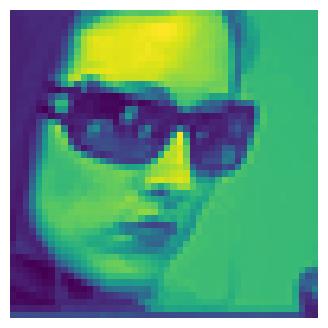

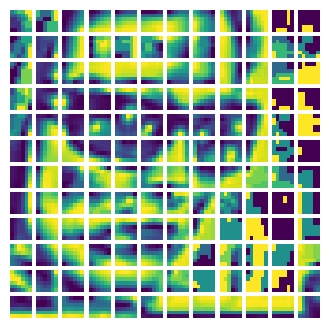

In [50]:
plt.figure(figsize=(4, 4))
image = x_train[np.random.choice(range(x_train.shape[0]))]
plt.imshow(image.astype("uint8"))
plt.axis("off")

resized_image = ops.image.resize(
    ops.convert_to_tensor([image]), size=(image_size, image_size)
)
patches = Patches(patch_size)(resized_image)
print(f"Image size: {image_size} X {image_size}")
print(f"Patch size: {patch_size} X {patch_size}")
print(f"Patches per image: {patches.shape[1]}")
print(f"Elements per patch: {patches.shape[-1]}")

n = int(np.sqrt(patches.shape[1]))
plt.figure(figsize=(4, 4))
for i, patch in enumerate(patches[0]):
    ax = plt.subplot(n, n, i + 1)
    patch_img = ops.reshape(patch, (patch_size, patch_size, 1))
    plt.imshow(ops.convert_to_numpy(patch_img).astype("uint8"))
    plt.axis("off")

## Implement the patch encoding layer

The PatchEncoder layer will linearly transform a patch by projecting it into a vector of size projection_dim.  
In addition, it adds a learnable position embedding to the projected vector.

In [51]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = ops.expand_dims(
            ops.arange(start=0, stop=self.num_patches, step=1), axis=0
        )
        projected_patches = self.projection(patch)
        encoded = projected_patches + self.position_embedding(positions)
        return encoded

    def get_config(self):
        config = super().get_config()
        config.update({"num_patches": self.num_patches})
        return config

## Build the ViT model

In [52]:
def create_vit_classifier():
    inputs = keras.Input(shape=input_shape)
    # Augment data.
    augmented = data_augmentation(inputs)
    # Create patches.
    patches = Patches(patch_size)(augmented)
    # Encode patches.
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    # Create multiple layers of the Transformer block.
    for _ in range(transformer_layers):
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        # Skip connection 1.
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP.
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        # Skip connection 2.
        encoded_patches = layers.Add()([x3, x2])

    # Create a [batch_size, projection_dim] tensor.
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)
    # Add MLP.
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.5)
    # Classify outputs.
    logits = layers.Dense(num_classes)(features)
    # Create the Keras model.
    model = keras.Model(inputs=inputs, outputs=logits)
    return model

## Compile, train, and evaluate the mode

In [53]:
def run_experiment(model):
    optimizer = keras.optimizers.AdamW(
        learning_rate=learning_rate, weight_decay=weight_decay
    )

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
            keras.metrics.SparseTopKCategoricalAccuracy(5, name="top-5-accuracy"),
        ],
    )

    checkpoint_filepath = "/tmp/checkpoint.weights.h5"
    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkpoint_filepath,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
    )

    history = model.fit(
        x=x_train,
        y=y_train,
        batch_size=batch_size,
        epochs=num_epochs,
        validation_split=0.1,
        callbacks=[checkpoint_callback],
    )

    model.load_weights(checkpoint_filepath)
    _, accuracy, top_5_accuracy = model.evaluate(x_test, y_test)
    print(f"Test accuracy: {round(accuracy * 100, 2)}%")
    print(f"Test top 5 accuracy: {round(top_5_accuracy * 100, 2)}%")

    return history


vit_classifier = create_vit_classifier()
vit_classifier.summary()
history = run_experiment(vit_classifier)


def plot_history(item):
    plt.plot(history.history[item], label=item)
    plt.plot(history.history["val_" + item], label="val_" + item)
    plt.xlabel("Epochs")
    plt.ylabel(item)
    plt.title("Train and Validation {} Over Epochs".format(item), fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()


plot_history("loss")
plot_history("top-5-accuracy")

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃ Param # ┃ Connected to         ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 48, 48, 1) │       0 │ -                    │
│ (InputLayer)        │                   │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ data_augmentation   │ (None, 72, 72, 1) │       3 │ input_layer_4[0][0]  │
│ (Sequential)        │                   │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ patches_5 (Patches) │ (None, 144, 36)   │       0 │ data_augmentation[0… │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ patch_encoder_2     │ (None, 144, 64)   │  11,584 │ patches_5[0][0]      │
│ (PatchEncoder)      │                   │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ layer_normalizatio… │ (None, 144, 64)   │     128 │ patch_encoder_2[0][… │
│ (LayerNormalizatio… │                   │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ multi_head_attenti… │ (None, 144, 64)   │  66,368 │ layer_normalization… │
│ (MultiHeadAttentio… │                   │         │ layer_normalization… │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ add_32 (Add)        │ (None, 144, 64)   │       0 │ multi_head_attentio… │
│                     │                   │         │ patch_encoder_2[0][… │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ layer_normalizatio… │ (None, 144, 64)   │     128 │ add_32[0][0]         │
│ (LayerNormalizatio… │                   │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ dense_40 (Dense)    │ (None, 144, 128)  │   8,320 │ layer_normalization… │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ dropout_55          │ (None, 144, 128)  │       0 │ dense_40[0][0]       │
│ (Dropout)           │                   │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ dense_41 (Dense)    │ (None, 144, 64)   │   8,256 │ dropout_55[0][0]     │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ dropout_56          │ (None, 144, 64)   │       0 │ dense_41[0][0]       │
│ (Dropout)           │                   │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ add_33 (Add)        │ (None, 144, 64)   │       0 │ dropout_56[0][0],    │
│                     │                   │         │ add_32[0][0]         │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ layer_normalizatio… │ (None, 144, 64)   │     128 │ add_33[0][0]         │
│ (LayerNormalizatio… │                   │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ multi_head_attenti… │ (None, 144, 64)   │  66,368 │ layer_normalization… │
│ (MultiHeadAttentio… │                   │         │ layer_normalization… │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ add_34 (Add)        │ (None, 144, 64)   │       0 │ multi_head_attentio… │
│                     │                   │         │ add_33[0][0]         │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ layer_normalizatio… │ (None, 144, 64)   │     128 │ add_34[0][0]         │
│ (LayerNormalizatio… │                   │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ dense_42 (Dense)    │ (None, 144, 128)  │   8,320 │ layer_normalization

 Total params: 21,659,082 (82.62 MB)

 Trainable params: 21,659,079 (82.62 MB)

 Non-trainable params: 3 (12.00 B)

ValueError: Incompatible shapes for broadcasting: shapes=[(128, 7), (128,)]